# Graded Response Model — Duckworth Grit Scale (Single Scale)

Fits a single-dimensional GRM to all 12 Grit Scale items.

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ['JAX_PLATFORMS'] = 'cpu'

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

## 1. Load Data

In [2]:
from bayesianquilts.data.grit import get_data, item_keys, response_cardinality

df, num_people = get_data(polars_out=True)
print(f"Dataset: {num_people} people, {len(item_keys)} items, {response_cardinality} response categories (0-{response_cardinality - 1})")
print(f"Item keys: {item_keys}")
df.head()

Dataset: 4270 people, 12 items, 5 response categories (0-4)
Item keys: ['GS1', 'GS2', 'GS3', 'GS4', 'GS5', 'GS6', 'GS7', 'GS8', 'GS9', 'GS10', 'GS11', 'GS12']


person,GS1,GS2,GS3,GS4,GS5,GS6,GS7,GS8,GS9,GS10,GS11,GS12
u32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,0,0,2,2,2,1,2,0,2,1,2,2
1,1,1,2,2,1,0,2,2,1,0,2,1
2,2,2,2,2,3,2,3,3,2,2,2,2
3,0,2,3,1,3,0,4,3,0,0,2,0
4,0,1,2,2,1,1,1,3,2,2,3,3


In [3]:
SUBSAMPLE_N = num_people
sub_df = df
print(f"Using full dataset: N = {SUBSAMPLE_N}")

Using full dataset: N = 4270


## 2. Prepare Data

In [4]:
def make_data_dict(dataframe):
    data = {}
    for col in dataframe.columns:
        arr = dataframe[col].to_numpy().astype(np.float64)
        data[col] = arr
    data['person'] = np.arange(len(dataframe), dtype=np.float64)
    return data

batch = make_data_dict(sub_df)

# Check for missing/invalid values
n_bad = sum(
    np.sum(np.isnan(batch[k]) | (batch[k] < 0) | (batch[k] >= response_cardinality))
    for k in item_keys
)
print(f"Bad/missing values: {n_bad}")

BATCH_SIZE = 256
steps_per_epoch = int(np.ceil(SUBSAMPLE_N / BATCH_SIZE))
print(f"N: {SUBSAMPLE_N}, Batch size: {BATCH_SIZE}, Steps per epoch: {steps_per_epoch}")

def data_factory():
    indices = np.arange(SUBSAMPLE_N)
    np.random.shuffle(indices)
    for start in range(0, SUBSAMPLE_N, BATCH_SIZE):
        end = min(start + BATCH_SIZE, SUBSAMPLE_N)
        idx_batch = indices[start:end]
        yield {k: v[idx_batch] for k, v in batch.items()}

Bad/missing values: 183
N: 4270, Batch size: 256, Steps per epoch: 17


## 3. Fit Baseline GRM (Ignorable Missingness)

In [5]:
from bayesianquilts.irt.grm import GRModel

model_baseline = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    kappa_scale=0.1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
)

NUM_EPOCHS = 200
SNAPSHOT_EPOCH = 50  # save early checkpoint for warm-starting imputed model

res_baseline = model_baseline.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    zero_nan_grads=True,
    snapshot_epoch=SNAPSHOT_EPOCH,
)

losses_baseline = res_baseline[0]
snapshot_params = res_baseline[2] if len(res_baseline) > 2 else None
print(f"Final baseline loss: {losses_baseline[-1]:.2f}")
if snapshot_params is not None:
    print(f"Snapshot saved at epoch {SNAPSHOT_EPOCH}")

--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.5
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'eta\\softplus\\normal\\loc', 'eta\\softplus\\normal\\scale', 'kappa\\softplus\\igamma\\concentration', 'kappa\\softplus\\igamma\\scale', 'kappa_a\\softplus\\igamma\\concentration', 'kappa_a\\softplus\\igamma\\scale', 'abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/17 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/17 [00:04<?, ?batch/s, best_loss=inf, loss=16512.0270]

Epoch 1/200 (LR: 0.000200):   6%|▌         | 1/17 [00:04<01:07,  4.24s/batch, best_loss=inf, loss=16512.0270]

Epoch 1/200 (LR: 0.000200):   6%|▌         | 1/17 [00:04<01:07,  4.24s/batch, best_loss=inf, loss=16851.4198]

...

Epoch 200/200 (LR: 0.000200):  82%|████████▏ | 14/17 [00:00<00:00, 136.68batch/s, best_loss=6189.0111, loss=6254.3360]

Epoch 200/200 (LR: 0.000200):  82%|████████▏ | 14/17 [00:00<00:00, 136.68batch/s, best_loss=6189.0111, loss=6333.0622]

Epoch 200/200 (LR: 0.000200):  82%|████████▏ | 14/17 [00:00<00:00, 136.68batch/s, best_loss=6189.0111, loss=4404.1665]

  -> New best loss found. Checkpoint saved.                    

--- Training Finished ---


Final baseline loss: 6176.70
Snapshot saved at epoch 50


In [6]:
model_baseline.save_to_disk('grm_baseline')

In [7]:
# Calibrate baseline model early so we can compute WAIC for mixed imputation
def calibrate_manually(model, n_samples=32, seed=42):
    surrogate = model.surrogate_distribution_generator(model.params)
    key = jax.random.PRNGKey(seed)
    samples = surrogate.sample(n_samples, seed=key)
    expectations = {k: jnp.mean(v, axis=0) for k, v in samples.items()}
    model.calibrated_expectations = expectations
    model.surrogate_sample = samples

calibrate_manually(model_baseline, n_samples=32, seed=101)

## 4. Fit MICEBayesianLOO Imputation Model

In [8]:
from bayesianquilts.imputation.mice_loo import MICEBayesianLOO

# Convert to pandas, replacing -1 (missing marker) with NaN
pandas_df = sub_df.select(item_keys).to_pandas()
pandas_df = pandas_df.replace(-1, np.nan)
print(f"Missing values per item:\n{pandas_df.isna().sum()}")

mice_loo = MICEBayesianLOO(
    random_state=42,
    prior_scale=1.0,
    pathfinder_num_samples=100,
    pathfinder_maxiter=50,
    batch_size=512,
    verbose=True,
)

mice_loo.fit_loo_models(
    pandas_df,
    n_top_features=12,
    n_jobs=1,
    fit_zero_predictors=True,
    seed=42,
)

Missing values per item:
GS1     10
GS2     14
GS3     12
GS4     34
GS5     11
GS6     14
GS7     14
GS8     10
GS9      9
GS10    15
GS11    15
GS12    25
dtype: int64
Computing feature correlations...
Fitting MICE Bayesian LOO-CV models with Pathfinder
  Variables: 12
  Observations: 4270
  Min obs per model: 5
  Parallel jobs: 1
  Top features per target: 12
  Global Ordinal Values: [0. 1. 2. 3. 4.] (n=5)

Fitting zero-predictor models...
  Scheduling 12 zero-predictor jobs...


  Var 0 (GS1): n_obs=4260, elpd/n=-0.1579


  Var 1 (GS2): n_obs=4256, elpd/n=-0.1790


  Var 2 (GS3): n_obs=4258, elpd/n=-0.1841


  Var 3 (GS4): n_obs=4236, elpd/n=-0.1846


...

  Processing GS8 (11 valid predictors)


  Processing GS9 (11 valid predictors)


  Processing GS10 (11 valid predictors)


  Processing GS11 (11 valid predictors)


  Processing GS12 (11 valid predictors)


In [9]:
mice_loo.save('mice_loo_model.yaml')

In [10]:
from bayesianquilts.imputation.mixed import IrtMixedImputationModel

mixed_imputation = IrtMixedImputationModel(
    irt_model=model_baseline,
    mice_model=mice_loo,
    data_factory=data_factory,
    irt_elpd_batch_size=4,
)

print(mixed_imputation.summary())

Item Weights (MICE vs IRT):
Item           w_mice  ELPD_mice   ELPD_irt
--------------------------------------------
GS1             0.833    -0.1450    -1.7503
GS2             0.893    -0.1583    -2.2796
GS3             0.884    -0.1702    -2.2042
GS4             0.875    -0.1773    -2.1198
GS5             0.875    -0.1695    -2.1109
GS6             0.857     0.0495    -1.7383
GS7             0.897    -0.1607    -2.3290
GS8             0.884    -0.1639    -2.1937
GS9             0.873    -0.1555    -2.0822
GS10            0.838    -0.1695    -1.8125
GS11            0.836    -0.1648    -1.7907
GS12            0.900     0.0400    -2.1594


## 5. Fit GRM with Analytic Rao-Blackwellized Imputation

In [11]:
model_imputed = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    kappa_scale=0.1,
    response_cardinality=response_cardinality,
    imputation_model=mixed_imputation,
    dtype=jnp.float64,
)

if snapshot_params is not None:
    print(f"Warm-starting from baseline epoch-{SNAPSHOT_EPOCH} snapshot")

res_imputed = model_imputed.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    zero_nan_grads=True,
    initial_values=snapshot_params,
)

losses_imputed = res_imputed[0]
print(f"Final imputed loss: {losses_imputed[-1]:.2f}")

Warm-starting from baseline epoch-50 snapshot
--- Starting Training ---
Patience for early stopping: 10 epochs
LR decay factor on plateau: 0.5
Convergence will be checked every: 1 epoch(s)
Checkpoints will be saved to: None
Optimizing keys: ['abilities\\identity\\normal\\loc', 'abilities\\identity\\normal\\scale', 'ddifficulties\\softplus\\normal\\loc', 'ddifficulties\\softplus\\normal\\scale', 'difficulties0\\identity\\normal\\loc', 'difficulties0\\identity\\normal\\scale', 'discriminations\\softplus\\normal\\loc', 'discriminations\\softplus\\normal\\scale', 'eta\\softplus\\normal\\loc', 'eta\\softplus\\normal\\scale', 'kappa\\softplus\\igamma\\concentration', 'kappa\\softplus\\igamma\\scale', 'kappa_a\\softplus\\igamma\\concentration', 'kappa_a\\softplus\\igamma\\scale', 'mu\\identity\\normal\\loc', 'mu\\identity\\normal\\scale']
-------------------------


Epoch 1/200 (LR: 0.000200):   0%|          | 0/17 [00:00<?, ?batch/s]

Epoch 1/200 (LR: 0.000200):   0%|          | 0/17 [00:04<?, ?batch/s, best_loss=inf, loss=9568.1173]

Epoch 1/200 (LR: 0.000200):   6%|▌         | 1/17 [00:04<01:05,  4.11s/batch, best_loss=inf, loss=9568.1173]

Epoch 1/200 (LR: 0.000200):   6%|▌         | 1/17 [00:04<01:05,  4.11s/batch, best_loss=inf, loss=9862.4868]

...

Epoch 200/200 (LR: 0.000200):  71%|███████   | 12/17 [00:00<00:00, 111.46batch/s, best_loss=5055.8605, loss=5190.7115]

Epoch 200/200 (LR: 0.000200):  71%|███████   | 12/17 [00:00<00:00, 111.46batch/s, best_loss=5055.8605, loss=5120.4162]

Epoch 200/200 (LR: 0.000200):  71%|███████   | 12/17 [00:00<00:00, 111.46batch/s, best_loss=5055.8605, loss=3542.7937]

  -> New best loss found. Checkpoint saved.                    

--- Training Finished ---


Final imputed loss: 5050.19


In [12]:
model_imputed.save_to_disk('grm_imputed')

## 6. Compare Results

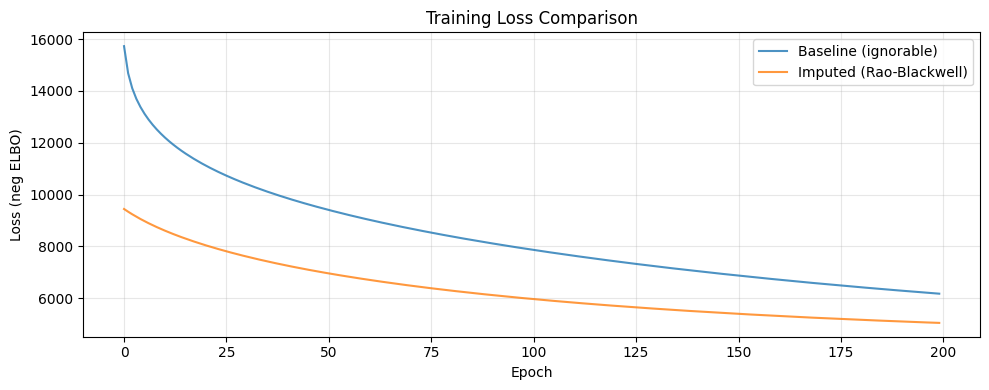

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(losses_baseline, alpha=0.8, label='Baseline (ignorable)')
ax.plot(losses_imputed, alpha=0.8, label='Imputed (Rao-Blackwell)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (neg ELBO)')
ax.set_title('Training Loss Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# calibrate_manually already defined above; just calibrate the imputed model
calibrate_manually(model_imputed, n_samples=32, seed=102)

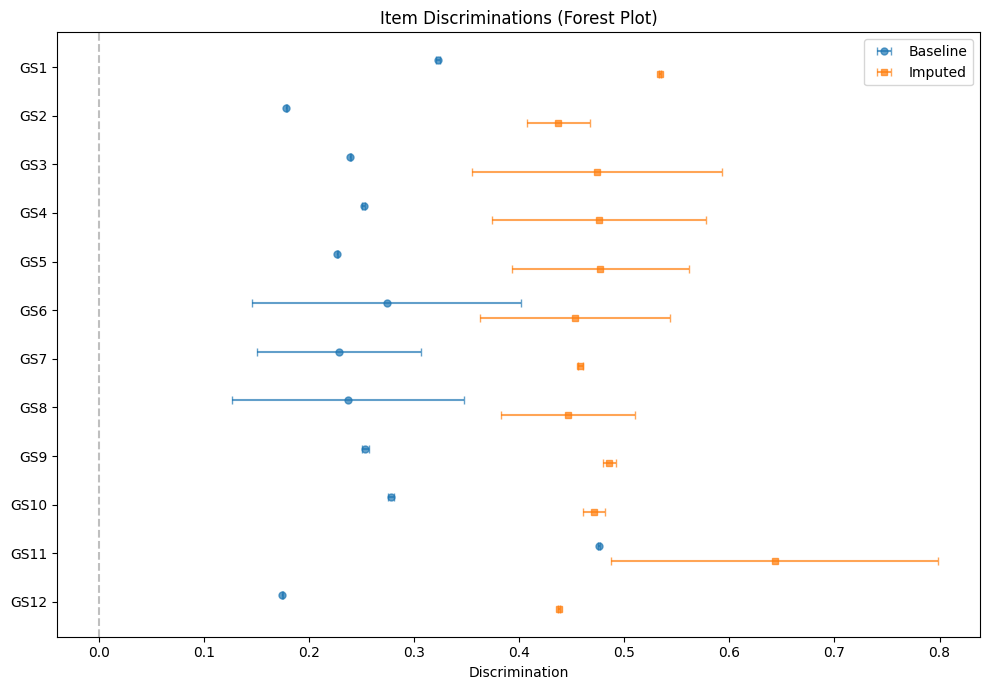

In [15]:
# Forest plot of discriminations with uncertainty
disc_samples_base = np.array(model_baseline.surrogate_sample['discriminations']).reshape(
    -1, len(item_keys))
disc_samples_imp = np.array(model_imputed.surrogate_sample['discriminations']).reshape(
    -1, len(item_keys))

disc_mean_base = disc_samples_base.mean(axis=0)
disc_std_base = disc_samples_base.std(axis=0)
disc_mean_imp = disc_samples_imp.mean(axis=0)
disc_std_imp = disc_samples_imp.std(axis=0)

fig, ax = plt.subplots(figsize=(10, max(7, len(item_keys) * 0.4)))
y_pos = np.arange(len(item_keys))
offset = 0.15

ax.errorbar(disc_mean_base, y_pos - offset, xerr=disc_std_base, fmt='o',
            capsize=3, markersize=5, elinewidth=1.5, color='tab:blue',
            ecolor='tab:blue', alpha=0.7, label='Baseline')
ax.errorbar(disc_mean_imp, y_pos + offset, xerr=disc_std_imp, fmt='s',
            capsize=3, markersize=5, elinewidth=1.5, color='tab:orange',
            ecolor='tab:orange', alpha=0.7, label='Imputed')

ax.set_yticks(y_pos)
ax.set_yticklabels(item_keys)
ax.set_xlabel('Discrimination')
ax.set_title('Item Discriminations (Forest Plot)')
ax.legend()
ax.invert_yaxis()
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

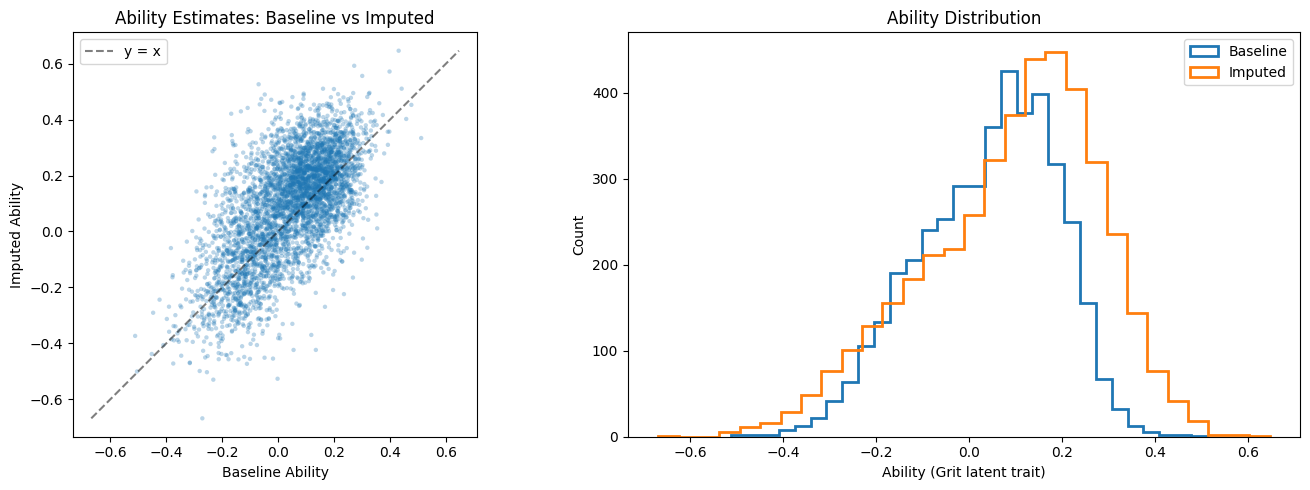

In [16]:
ab_base = np.array(model_baseline.calibrated_expectations['abilities']).flatten()
ab_imp = np.array(model_imputed.calibrated_expectations['abilities']).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(ab_base, ab_imp, alpha=0.3, s=10, edgecolors='none')
lims = [min(ab_base.min(), ab_imp.min()), max(ab_base.max(), ab_imp.max())]
ax.plot(lims, lims, 'k--', alpha=0.5, label='y = x')
ax.set_xlabel('Baseline Ability')
ax.set_ylabel('Imputed Ability')
ax.set_title('Ability Estimates: Baseline vs Imputed')
ax.legend()
ax.set_aspect('equal')

ax = axes[1]
ax.hist(ab_base, bins=30, histtype='step', linewidth=2, label='Baseline', color='tab:blue')
ax.hist(ab_imp, bins=30, histtype='step', linewidth=2, label='Imputed', color='tab:orange')
ax.set_xlabel('Ability (Grit latent trait)')
ax.set_ylabel('Count')
ax.set_title('Ability Distribution')
ax.legend()

plt.tight_layout()
plt.show()

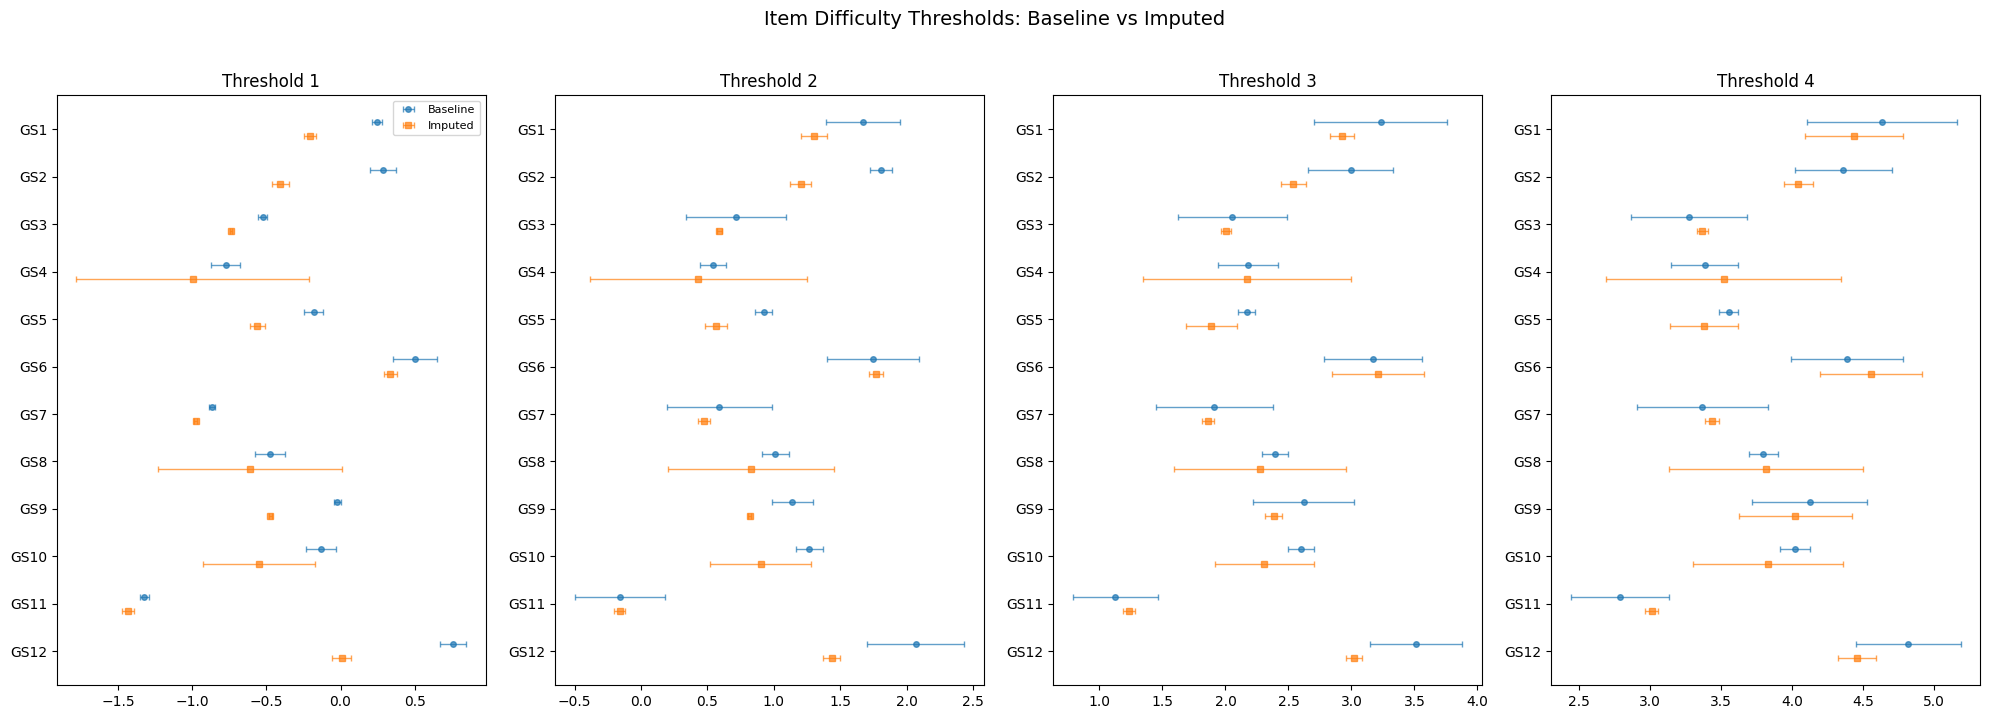

In [17]:
# Difficulty threshold comparison (panel for each level)
def compute_thresholds(model):
    diff0 = np.array(model.surrogate_sample['difficulties0'])
    ddiff = np.array(model.surrogate_sample['ddifficulties'])
    d0 = np.concatenate([diff0, ddiff], axis=-1)
    thresholds = np.cumsum(d0, axis=-1)
    n_samples = thresholds.shape[0]
    n_thresholds = thresholds.size // (n_samples * len(item_keys))
    return thresholds.reshape(n_samples, len(item_keys), n_thresholds)

thresh_base = compute_thresholds(model_baseline)
thresh_imp = compute_thresholds(model_imputed)

K_minus_1 = thresh_base.shape[-1]
n_cols = min(4, K_minus_1)
n_rows = int(np.ceil(K_minus_1 / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
    figsize=(5 * n_cols, max(7, len(item_keys) * 0.4) * n_rows),
    squeeze=False)

for level in range(K_minus_1):
    ax = axes[level // n_cols, level % n_cols]
    y_pos = np.arange(len(item_keys))

    mean_base = thresh_base[:, :, level].mean(axis=0)
    std_base = thresh_base[:, :, level].std(axis=0)
    mean_imp = thresh_imp[:, :, level].mean(axis=0)
    std_imp = thresh_imp[:, :, level].std(axis=0)

    offset = 0.15
    ax.errorbar(mean_base, y_pos - offset, xerr=std_base, fmt='o',
                capsize=2, markersize=4, elinewidth=1, color='tab:blue',
                alpha=0.7, label='Baseline')
    ax.errorbar(mean_imp, y_pos + offset, xerr=std_imp, fmt='s',
                capsize=2, markersize=4, elinewidth=1, color='tab:orange',
                alpha=0.7, label='Imputed')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(item_keys)
    ax.set_title(f'Threshold {level + 1}')
    ax.invert_yaxis()
    if level == 0:
        ax.legend(fontsize=8)

for idx in range(K_minus_1, n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

fig.suptitle('Item Difficulty Thresholds: Baseline vs Imputed', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

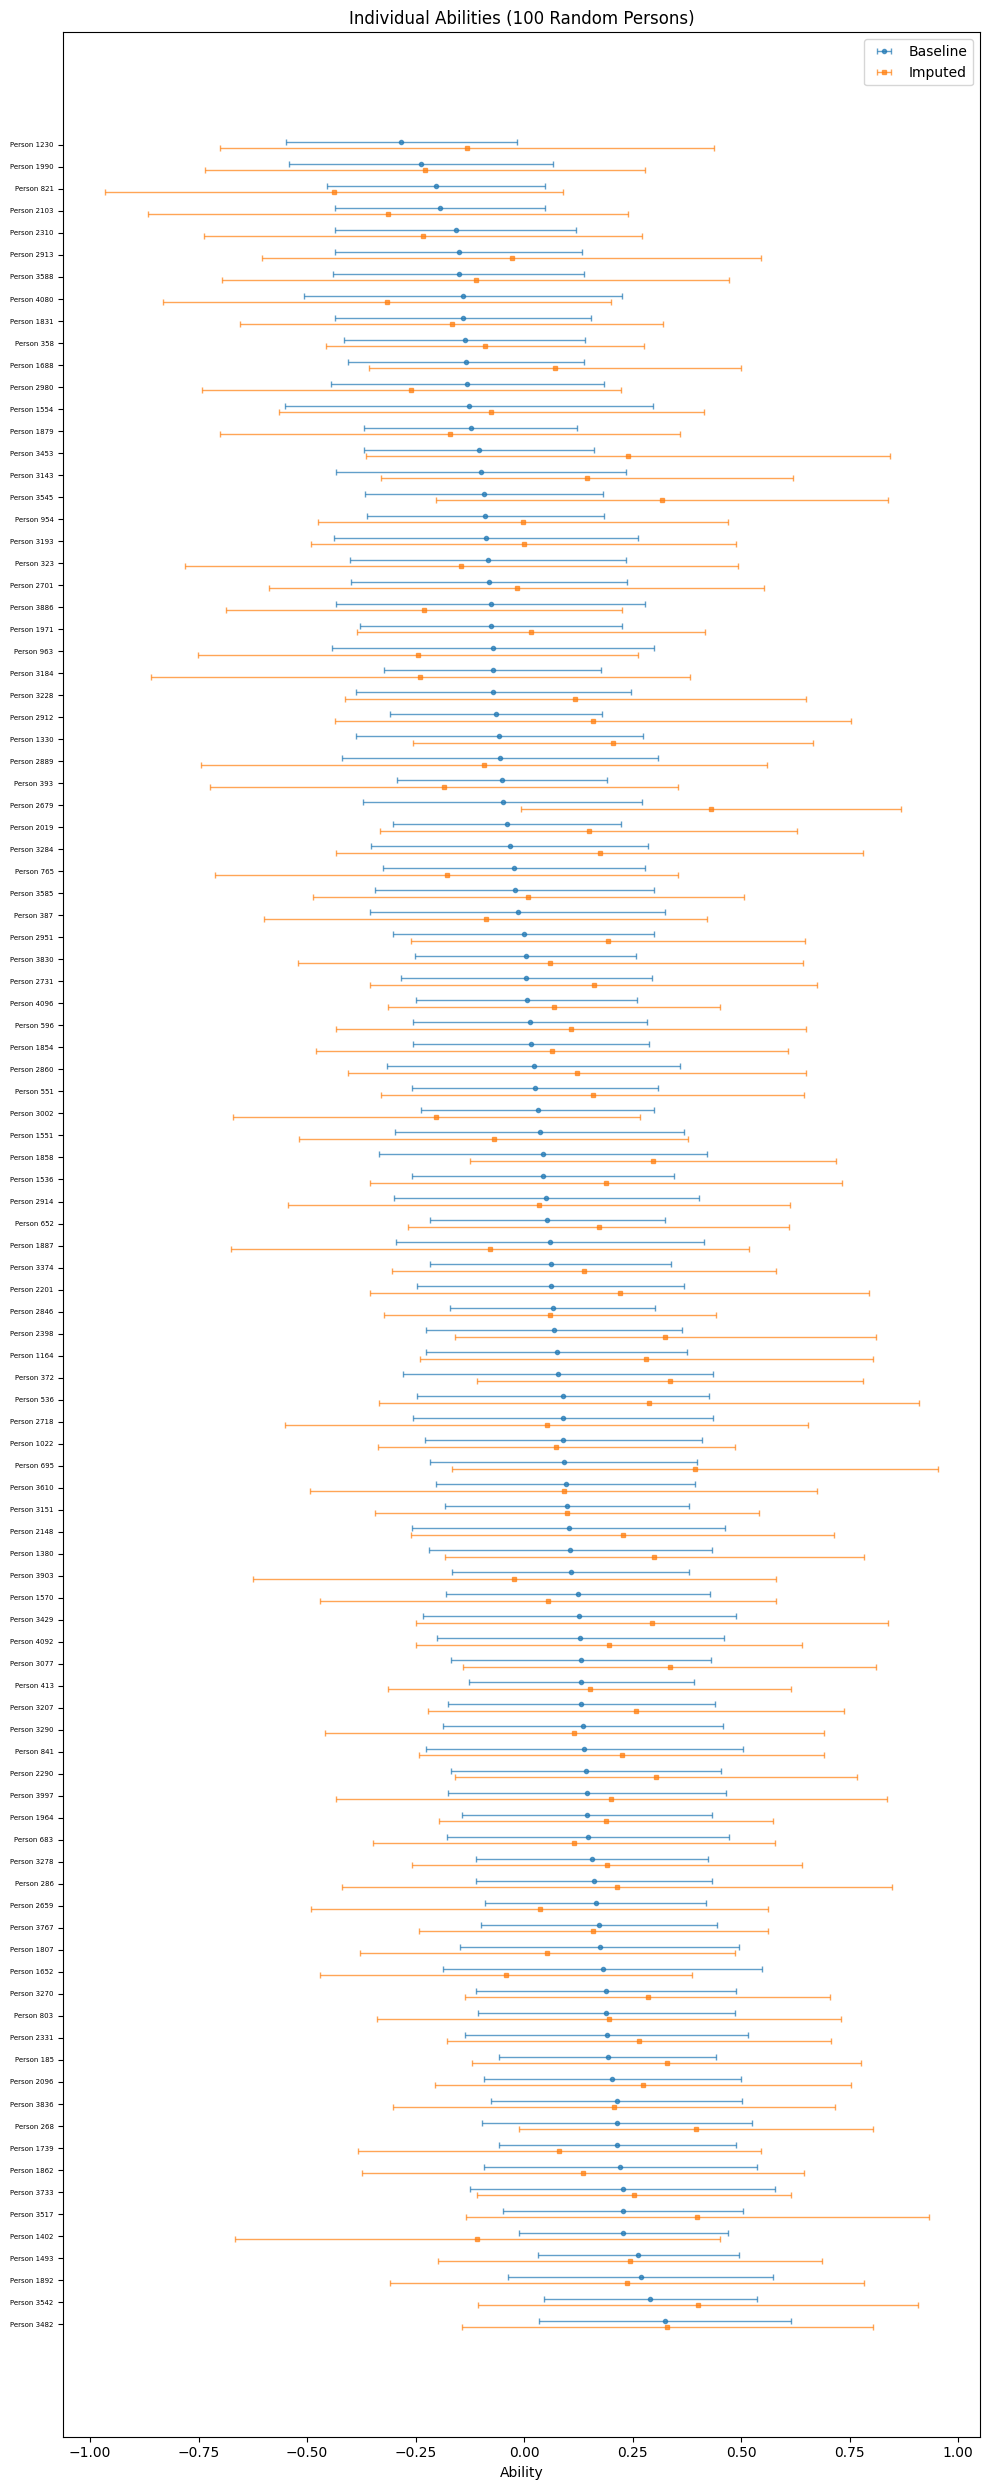

In [18]:
# Forest plot comparing abilities for 100 random individuals
ab_samples_base = np.array(model_baseline.surrogate_sample['abilities'])
ab_samples_imp = np.array(model_imputed.surrogate_sample['abilities'])

ab_samples_base = ab_samples_base.reshape(ab_samples_base.shape[0], -1)
ab_samples_imp = ab_samples_imp.reshape(ab_samples_imp.shape[0], -1)

N = ab_samples_base.shape[1]
rng = np.random.default_rng(42)
idx = rng.choice(N, size=min(100, N), replace=False)
idx = np.sort(idx)

ab_mean_base = ab_samples_base[:, idx].mean(axis=0)
ab_std_base = ab_samples_base[:, idx].std(axis=0)
ab_mean_imp = ab_samples_imp[:, idx].mean(axis=0)
ab_std_imp = ab_samples_imp[:, idx].std(axis=0)

order = np.argsort(ab_mean_base)
ab_mean_base = ab_mean_base[order]
ab_std_base = ab_std_base[order]
ab_mean_imp = ab_mean_imp[order]
ab_std_imp = ab_std_imp[order]

fig, ax = plt.subplots(figsize=(10, 25))
y_pos = np.arange(len(idx))
offset = 0.15

ax.errorbar(ab_mean_base, y_pos - offset, xerr=ab_std_base, fmt='o',
            capsize=2, markersize=3, elinewidth=1, color='tab:blue',
            alpha=0.7, label='Baseline')
ax.errorbar(ab_mean_imp, y_pos + offset, xerr=ab_std_imp, fmt='s',
            capsize=2, markersize=3, elinewidth=1, color='tab:orange',
            alpha=0.7, label='Imputed')

ax.set_yticks(y_pos)
ax.set_yticklabels([f'Person {i}' for i in idx[order]], fontsize=5)
ax.set_xlabel('Ability')
ax.set_title('Individual Abilities (100 Random Persons)')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated fitting a single-scale Graded Response Model to
all 12 Duckworth Grit Scale items (GS1--GS12) with 5 response categories (0--4).

Two models were compared:

1. **Baseline GRM** -- treats missing responses as ignorable (zeroes out their
   log-likelihood contribution).
2. **Imputed GRM** -- uses a MICEBayesianLOO imputation model to analytically
   marginalize over the imputation distribution for missing cells via
   Rao-Blackwellization.

The discrimination parameters indicate how well each item differentiates
respondents along the single Grit dimension. Comparing the two models
shows the effect of explicitly modelling missingness on parameter estimates.